# FHR-DQN vs baseline DQN — MountainCar comparison

One config (`configs/config_fhrdqn.yaml`), one code path (`FHRDQNAgent`), one difference:
the **baseline arm** strips the FHR term (`fhr_weight: 0.0`, which reproduces plain
`QAgent` training exactly — verified bit-for-bit in `tests/test_fhrdqn.py`), the
**FHR arm** runs the config as-is. Both arms train once per seed in
`experiment.seeds`, fanned out as **parallel subprocesses** by
`../../src/run_fhrdqn_seeds.py` (which also defines the Q-network; each child re-seeds
torch/numpy/random via `load_config(CONFIG, seed=s)`, so per-seed pairs start
from identical seed state), and every comparison figure reports the seed-average.

MountainCar trains mid-episode (`use_episode_training: False`), so `train_diagnostics.csv`
holds one row per gradient step — the comparison plots aggregate per episode.
The baseline `exp1.ipynb` run showed the greedy-rollout Hankel of Q/V collapsing to
effective rank 1–2 from episode 50 onward (the constant `-1`/step reward makes the
Bellman recurrence roots {1, 1/gamma}), so the order-2 pure-AR penalty targets
structure that is genuinely present here.

The low-rank Hankel sweep and the Q-matrix rank tracking
(`analysis.hankel_sweep.enabled: true`, `analysis.methods: q_matrix_dqn`) are ON
by default, so every run records the mechanism diagnostics alongside the reward
curves. Toggles to explore after this run (edit the config, rerun):
- `reward_lags: True` — ARX variant: learned reward-lag coefficients `d_k`, makes the exact Bellman recurrence representable at order 1.
- `analysis.autoregressive_value_probe.enabled: true` — held-out AR-fit diagnostics of the frozen greedy policy's value sequences.

All artifacts land under `runs/<name>_<timestamp>/` and are browsable in the web app:
`python result_viewer_app/rank_viewer.py` → the *Training diagnostics* card shows the
TD loss, penalty and coefficient curves per run.


In [1]:
import csv, sys, pathlib, warnings
import matplotlib.pyplot as plt
import numpy as np

# NaN-padded seed stacks legitimately have all-NaN columns (episodes before
# training starts / after early-stopped seeds end) — nanmean warns, we don't care.
warnings.filterwarnings("ignore", message="Mean of empty slice")

EXPS = pathlib.Path.cwd().parents[1] / "src"   # experiments/src — hosts the shared runner
if str(EXPS) not in sys.path:
    sys.path.insert(0, str(EXPS))

from run_fhrdqn_seeds import launch_all, load_runs

## Both arms, all seeds — parallel subprocess fan-out

`launch_all()` runs one training subprocess per (arm, seed): the baseline arm
strips the FHR term (`fhr_weight: 0.0` — the single difference), the FHR arm
runs the config as-is. The nets are tiny (~10–20% GPU each), so the fan-out
shares one GPU comfortably. Completed runs are recorded in
`cached/fhrdqn_runs_manifest.json` — re-running the cell only launches missing or
failed pairs (`force=True` reruns everything) — and each child logs to
`logs/fhrdqn_<arm>_seed<N>.log`.

In [2]:
manifest = launch_all(max_workers=6)
SEEDS = manifest["seeds"]
runs_base = load_runs("baseline")
[r["run_dir"] for r in runs_base]

skipping 6 already-completed run(s) recorded in fhrdqn_runs_manifest.json


[PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_baseline_seed21_20260811-222356'),
 PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_baseline_seed56_20260811-222356'),
 PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_baseline_seed102_20260811-222356')]

## FHR arm — config as-is

Loaded from the same manifest; `cfg_fhr` is the config copy saved into the FHR
run directory, i.e. what was actually trained.

In [3]:
runs_fhr = load_runs("fhr")
cfg_fhr = runs_fhr[0]["cfg"]
[r["run_dir"] for r in runs_fhr]

[PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_seed21_20260811-222356'),
 PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_seed56_20260811-222356'),
 PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_seed102_20260811-222356')]

## Comparison figures

All curves below are seed-averages (thin lines, where shown, are single seeds).
Each figure is shown inline and saved as `figures/comparison_<slug>.png` into
**every** run directory (both arms, all seeds), so any run's page in the result
viewer carries the full comparison.
Diagnostics are one row per gradient step here, so everything is aggregated to
per-episode means before the seed-average.

In [4]:
def read_diagnostics(run_dir):
    """train_diagnostics.csv -> {column: np.array}, aggregated to per-episode
    means (MountainCar logs one row per gradient step)."""
    path = pathlib.Path(run_dir) / "train_diagnostics.csv"
    with open(path) as f:
        rows = list(csv.DictReader(f))
    raw = {k: np.array([float(r[k]) for r in rows]) for k in rows[0]}
    episodes = np.unique(raw["episode"])
    agg = {"episode": episodes}
    for k, v in raw.items():
        if k == "episode":
            continue
        agg[k] = np.array([np.nanmean(v[raw["episode"] == e]) for e in episodes])
    return agg

diags_base = [read_diagnostics(r["run_dir"]) for r in runs_base]
diags_fhr = [read_diagnostics(r["run_dir"]) for r in runs_fhr]

ALL_RUN_DIRS = [r["run_dir"] for r in runs_base + runs_fhr]

def save_and_show(fig, slug):
    for d in ALL_RUN_DIRS:
        figdir = pathlib.Path(d) / "figures"
        figdir.mkdir(exist_ok=True)
        fig.savefig(figdir / f"comparison_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

def rolling(x, w=50):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

def stack_padded(seqs):
    """(n_seeds, max_len) array, NaN-padded on the right — early-stopped seeds
    are shorter, and the NaN-aware means below only average seeds still running."""
    out = np.full((len(seqs), max(len(s) for s in seqs)), np.nan)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
    return out

def seed_mean_rewards(runs):
    """Seed-mean episode-reward curve."""
    return np.nanmean(stack_padded([r["rewards"] for r in runs]), axis=0)

def diag_seed_mean(diags, key):
    """(episode axis, seed-mean curve) for one diagnostics column, aligned on
    the integer episode index and NaN-padded per seed."""
    n_ep = int(max(d["episode"].max() for d in diags)) + 1
    stack = np.full((len(diags), n_ep), np.nan)
    for i, d in enumerate(diags):
        stack[i, d["episode"].astype(int)] = d[key]
    return np.arange(n_ep), np.nanmean(stack, axis=0)

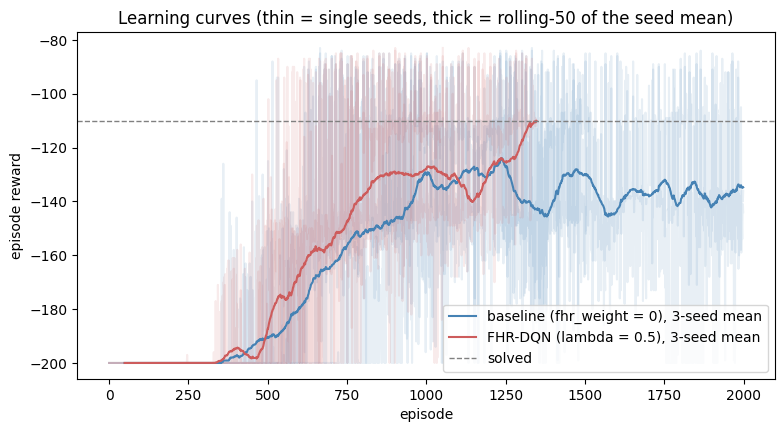

In [5]:
# -- learning curves ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
for r in runs_base:
    ax.plot(r["rewards"], alpha=0.12, color="steelblue")
for r in runs_fhr:
    ax.plot(r["rewards"], alpha=0.12, color="indianred")
mean_base = seed_mean_rewards(runs_base)
mean_fhr = seed_mean_rewards(runs_fhr)
ax.plot(np.arange(len(rolling(mean_base))) + 49, rolling(mean_base),
        color="steelblue", label=f"baseline (fhr_weight = 0), {len(SEEDS)}-seed mean")
ax.plot(np.arange(len(rolling(mean_fhr))) + 49, rolling(mean_fhr),
        color="indianred",
        label=f"FHR-DQN (lambda = {cfg_fhr['agent']['fhr_weight']}), {len(SEEDS)}-seed mean")
ax.axhline(cfg_fhr["training"]["solved_reward"], ls="--", c="gray", lw=1, label="solved")
ax.set_xlabel("episode"); ax.set_ylabel("episode reward")
ax.set_title("Learning curves (thin = single seeds, thick = rolling-50 of the seed mean)")
ax.legend()
save_and_show(fig, "learning_curves")

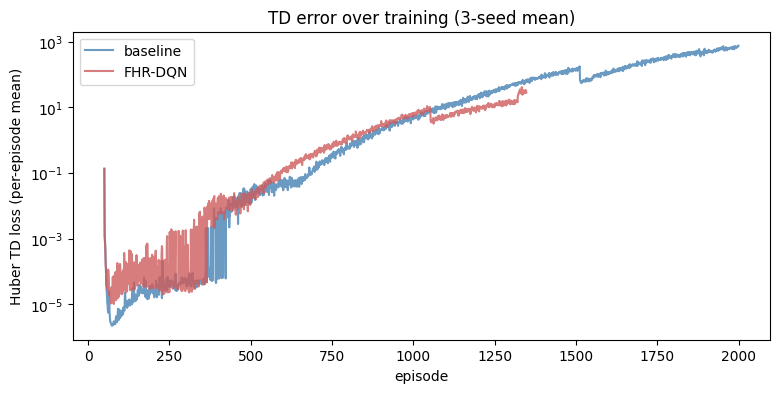

In [6]:
# -- TD error over training --------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(*diag_seed_mean(diags_base, "td_loss"), color="steelblue", alpha=0.8,
        label="baseline")
ax.plot(*diag_seed_mean(diags_fhr, "td_loss"), color="indianred", alpha=0.8,
        label="FHR-DQN")
ax.set_xlabel("episode"); ax.set_ylabel("Huber TD loss (per-episode mean)")
ax.set_yscale("log")
ax.set_title(f"TD error over training ({len(SEEDS)}-seed mean)")
ax.legend()
save_and_show(fig, "td_error")

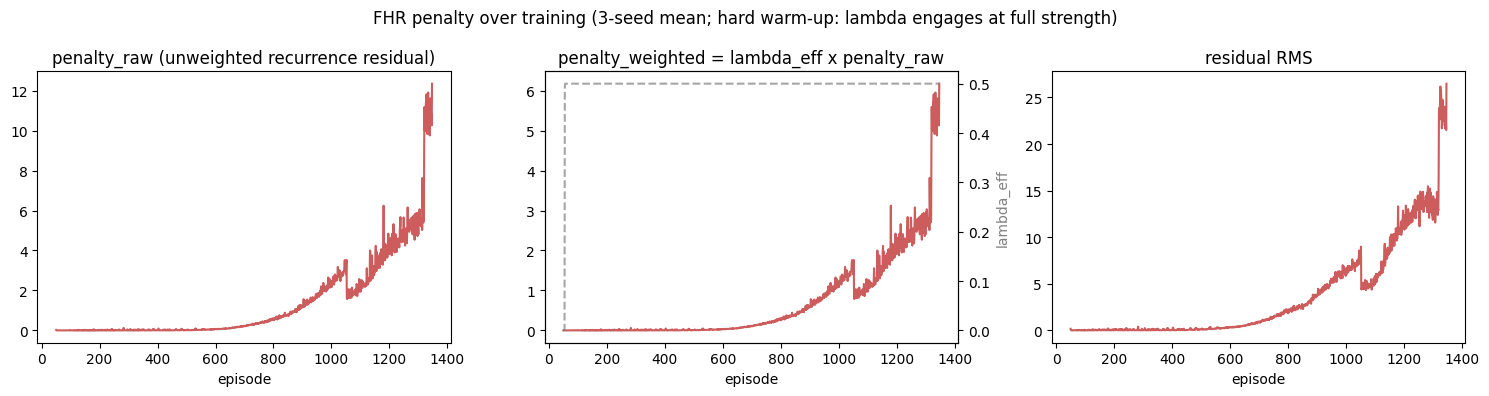

In [7]:
# -- regularisation penalty over training (seed means) -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(*diag_seed_mean(diags_fhr, "penalty_raw"), color="indianred")
axes[0].set_title("penalty_raw (unweighted recurrence residual)")
axes[1].plot(*diag_seed_mean(diags_fhr, "penalty_weighted"), color="indianred")
axes[1].set_title("penalty_weighted = lambda_eff x penalty_raw")
ax2 = axes[1].twinx()
ax2.plot(*diag_seed_mean(diags_fhr, "lambda_eff"), color="gray", ls="--", alpha=0.7)
ax2.set_ylabel("lambda_eff", color="gray")
axes[2].plot(*diag_seed_mean(diags_fhr, "residual_rms"), color="indianred")
axes[2].set_title("residual RMS")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle(f"FHR penalty over training ({len(SEEDS)}-seed mean; hard warm-up: lambda engages at full strength)")
fig.tight_layout()
save_and_show(fig, "penalty")

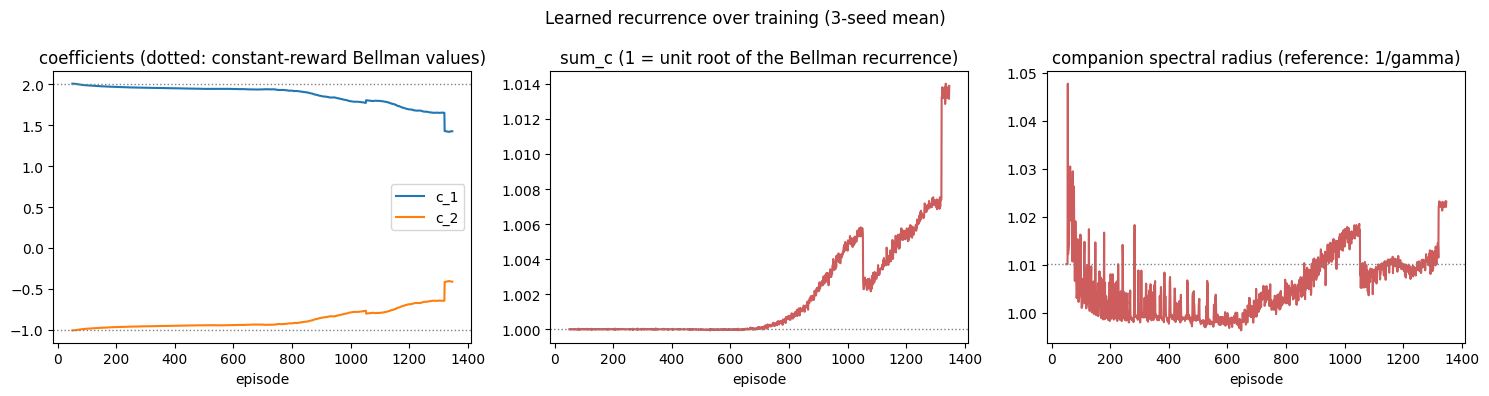

In [8]:
# -- learned recurrence coefficients (seed means) ----------------------------
gamma = cfg_fhr["agent"]["discount_factor"]
r = cfg_fhr["agent"]["fhr_order"]
c_cols = [f"c_{j}" for j in range(1, r + 1) if f"c_{j}" in diags_fhr[0]]
d_cols = [f"d_{j}" for j in range(1, r + 1) if f"d_{j}" in diags_fhr[0]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col in c_cols + d_cols:
    axes[0].plot(*diag_seed_mean(diags_fhr, col), label=col)
axes[0].axhline(1 + 1 / gamma, ls=":", c="gray", lw=1)
axes[0].axhline(-1 / gamma, ls=":", c="gray", lw=1)
axes[0].set_title("coefficients (dotted: constant-reward Bellman values)")
axes[0].legend()
axes[1].plot(*diag_seed_mean(diags_fhr, "sum_c"), color="indianred")
axes[1].axhline(1.0, ls=":", c="gray", lw=1)
axes[1].set_title("sum_c (1 = unit root of the Bellman recurrence)")
axes[2].plot(*diag_seed_mean(diags_fhr, "companion_radius"), color="indianred")
axes[2].axhline(1 / gamma, ls=":", c="gray", lw=1)
axes[2].set_title("companion spectral radius (reference: 1/gamma)")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle(f"Learned recurrence over training ({len(SEEDS)}-seed mean)")
fig.tight_layout()
save_and_show(fig, "coefficients")

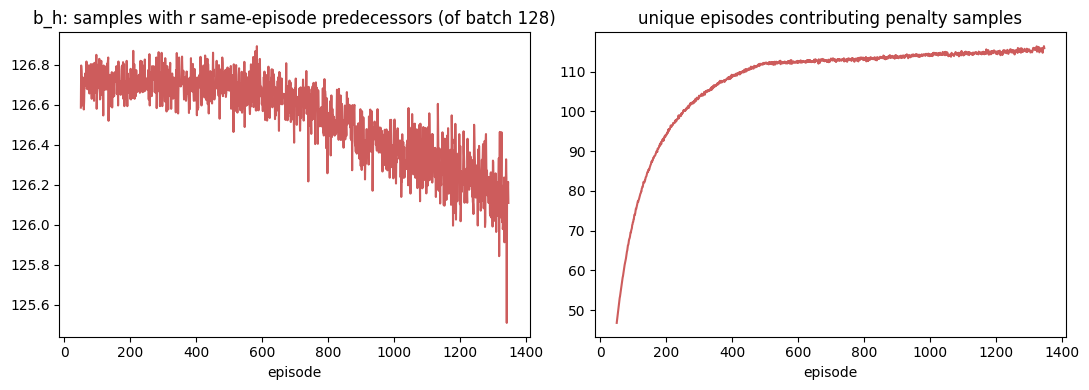

In [9]:
# -- penalty batch composition (seed means) ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(*diag_seed_mean(diags_fhr, "b_h"), color="indianred")
axes[0].set_title("b_h: samples with r same-episode predecessors (of batch %d)"
                  % cfg_fhr["agent"]["batch_size"])
axes[1].plot(*diag_seed_mean(diags_fhr, "unique_eps"), color="indianred")
axes[1].set_title("unique episodes contributing penalty samples")
for ax in axes:
    ax.set_xlabel("episode")
fig.tight_layout()
save_and_show(fig, "penalty_batch")

In [10]:
# -- summary -----------------------------------------------------------------
def solve_episode(rewards, solved, patience=50):
    roll = rolling(rewards, patience)
    idx = np.argmax(roll > solved)
    return int(idx + patience) if roll.max() > solved else None

solved = cfg_fhr["training"]["solved_reward"]
for label, runs in (("baseline", runs_base), ("FHR-DQN ", runs_fhr)):
    bests = [rolling(r["rewards"]).max() for r in runs]
    solves = [solve_episode(r["rewards"], solved) for r in runs]
    solved_eps = [s for s in solves if s is not None]
    mean_solve = f"{np.mean(solved_eps):.0f}" if solved_eps else "n/a"
    print(f"{label}: mean best rolling-50 {np.mean(bests):.1f} | "
          f"solved {len(solved_eps)}/{len(runs)} seeds | mean solve episode {mean_solve}")
    for r, b, s in zip(runs, bests, solves):
        print(f"    seed {r['seed']}: {len(r['rewards'])} episodes, "
              f"best rolling-50 {b:.1f}, solved at episode {s}")

final = {c: np.mean([d[c][-1] for d in diags_fhr])
         for c in c_cols + d_cols + ["sum_c", "companion_radius"]}
print("final coefficients (seed mean): "
      + ", ".join(f"{c}={final[c]:.4f}" for c in c_cols + d_cols)
      + f" | sum_c={final['sum_c']:.4f}"
      + f" | companion radius={final['companion_radius']:.4f} (1/gamma={1/gamma:.4f})")
print("nan_skips: baseline "
      + ", ".join(f"{d['nan_skips'][-1]:.0f}" for d in diags_base)
      + " | FHR " + ", ".join(f"{d['nan_skips'][-1]:.0f}" for d in diags_fhr))

baseline: mean best rolling-50 -112.9 | solved 1/3 seeds | mean solve episode 1512
    seed 21: 2000 episodes, best rolling-50 -117.9, solved at episode None
    seed 56: 1512 episodes, best rolling-50 -109.7, solved at episode 1512
    seed 102: 2000 episodes, best rolling-50 -111.0, solved at episode None
FHR-DQN : mean best rolling-50 -109.9 | solved 3/3 seeds | mean solve episode 1241
    seed 21: 1348 episodes, best rolling-50 -109.9, solved at episode 1348
    seed 56: 1053 episodes, best rolling-50 -109.8, solved at episode 1053
    seed 102: 1321 episodes, best rolling-50 -110.0, solved at episode 1321
final coefficients (seed mean): c_1=1.6706, c_2=-0.6618 | sum_c=1.0087 | companion radius=1.0190 (1/gamma=1.0101)
nan_skips: baseline 0, 0, 0 | FHR 0, 0, 0


## Mechanism: low-rank structure over training (seed-averaged)

Every run records the greedy-rollout Hankel sweep (`hankel_sweep.csv`) and the
state-grid Q-matrix rank (`rank_stats.csv`) every `analysis.ep_freq` episodes —
these curves are the mechanism claim: does the FHR penalty pull the
value-sequence Hankel toward the target rank faster than the baseline?
Per-episode spectra figures live in each run's `figures/` (browsable in the
result viewer).

In [ ]:
# -- Hankel effective rank over training (thin = seeds, thick = mean) ---------
def rank_rows(run_dir, csv_name, matrix, col="eff_rank"):
    """{episode: mean of `col` over rollouts} for one run."""
    with open(pathlib.Path(run_dir) / csv_name) as f:
        rows = [r for r in csv.DictReader(f) if r["matrix"] == matrix]
    eps = sorted({int(r["episode"]) for r in rows})
    return {e: np.mean([float(r[col]) for r in rows if int(r["episode"]) == e])
            for e in eps}

def arm_rank_stack(runs, csv_name, matrix, col="eff_rank"):
    """(episode axis, (n_seeds, n_ticks) NaN-padded stack) across an arm."""
    per = [rank_rows(r["run_dir"], csv_name, matrix, col) for r in runs]
    all_eps = sorted(set().union(*per))
    stack = np.array([[p.get(e, np.nan) for e in all_eps] for p in per], float)
    return np.array(all_eps), stack

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, matrix in zip(axes, ("Hankel Q", "Hankel V")):
    for runs, color, label in ((runs_base, "steelblue", "baseline"),
                               (runs_fhr, "indianred", "FHR-DQN")):
        eps, stack = arm_rank_stack(runs, "hankel_sweep.csv", matrix)
        for row in stack:
            ax.plot(eps, row, color=color, alpha=0.2)
        ax.plot(eps, np.nanmean(stack, axis=0), color=color, label=label)
    ax.axhline(cfg_fhr["agent"]["fhr_order"], ls=":", c="gray", lw=1)
    ax.set_title(f"{matrix} effective rank (dotted: fhr_order target)")
    ax.set_xlabel("episode")
axes[0].set_ylabel("effective rank (greedy rollouts)")
axes[0].legend()
fig.tight_layout()
save_and_show(fig, "hankel_rank_evolution")

In [ ]:
# -- state-grid Q-matrix rank over training ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ("eff_rank", "stable_rank")):
    for runs, color, label in ((runs_base, "steelblue", "baseline"),
                               (runs_fhr, "indianred", "FHR-DQN")):
        eps, stack = arm_rank_stack(runs, "rank_stats.csv", "Q-function", col)
        for row in stack:
            ax.plot(eps, row, color=color, alpha=0.2)
        ax.plot(eps, np.nanmean(stack, axis=0), color=color, label=label)
    ax.set_title(f"state-grid Q-matrix {col}")
    ax.set_xlabel("episode")
axes[0].legend()
fig.tight_layout()
save_and_show(fig, "q_matrix_rank")

## Final greedy policies (video)

One greedy episode per (arm, seed), rolled out from `checkpoints/final.pt`
through the exact training-time observation wrappers and reset with the run's
own seed; saved to `<run_dir>/videos/` and embedded below.

In [ ]:
from IPython.display import Video, display
from run_fhrdqn_seeds import record_final_videos

for label, arm in (("baseline", "baseline"), ("FHR-DQN", "fhr")):
    for seed, path in record_final_videos(arm):
        print(f"{label} — seed {seed}: {path.name}")
        display(Video(str(path), embed=True, width=420))